## ============================================================================

## E-COMMERCE FUNNEL ANALYTICS PROJECT
## NOTEBOOK: 04_BUSINESS_QUESTIONS

### PURPOSE:
### This notebook translates the funnel results into product, category, price,
### and session insights.

## ============================================================================

## Analysis objectives

This notebook answers four business questions:

1. Which products have high visibility but weak purchase activity?
2. Which categories show stronger or weaker conversion?
3. How does price relate to event-level conversion?
4. Do more engaged sessions have stronger funnel outcomes?

Product, category, and price metrics are event-based. Session metrics use the session-level table created in the funnel analysis notebook.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams.update({
    'font.family': 'Tahoma',
    'axes.titlesize': 14,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8
})

general_color = '#6670A3'
highlight_color = '#6CB54D'
warning_color = '#FFC400'
grid_color = '#E5E7EB'

def format_chart(ax):
    ax.grid(
        axis='both', 
        color=grid_color, 
        linewidth=0.8, 
        alpha=0.8)
    sns.despine(
        ax=ax, 
        top=True, 
        right=True)
    return ax

def add_event_rates(summary):
    summary['view_to_cart_rate'] = (
        summary['cart_count']
        .div(summary['view_count'])
        .mul(100)
        .where(summary['view_count'] > 0)
    )
    summary['view_to_purchase_rate'] = (
        summary['purchase_count']
        .div(summary['view_count'])
        .mul(100)
        .where(summary['view_count'] > 0)
    )
    return summary

## Load the analytical datasets

I will use the cleaned event-level dataset for product, category, and price
questions. I will use the session-level export for session engagement metrics.

In [5]:
events = pd.read_csv(
    '../data/processed/events_clean.csv',
    parse_dates=['event_time', 'event_date']
)

session_funnel = pd.read_csv(
    '../data/processed/tableau_funnel_sessions.csv',
    parse_dates=['session_start_date']
)

print(f'Cleaned event rows loaded: {len(events)}')
print(f'Session-level rows loaded: {len(session_funnel)}')

Cleaned event rows loaded: 884312
Session-level rows loaded: 490633


### QUESTION 1: 
## Which products have high visibility but weak purchase activity?

A product with many views and few purchases may represent an opportunity for
further investigation. Possible explanations include pricing, availability,
product relevance, or friction on the product detail page.

In [6]:
product_summary = (
    events.groupby('product_id', as_index=False)
    .agg(
        event_count=('event_type', 'size'),
        view_count=('event_type', lambda values: (values == 'view').sum()),
        cart_count=('event_type', lambda values: (values == 'cart').sum()),
        purchase_count=('event_type', lambda values: (values == 'purchase').sum()),
        average_price=('price', 'mean'),
        category_code=('category_code', 'first'),
        brand=('brand', 'first')
    )
)

product_summary = add_event_rates(product_summary)
high_visibility_threshold = product_summary['view_count'].quantile(0.90)

product_opportunities = (
    product_summary[product_summary['view_count'] >= high_visibility_threshold]
    .sort_values(['view_to_purchase_rate', 'view_count'], ascending=[True, False])
    .head(10)
)

print('High-visibility products with the lowest view-to-purchase rates:')
display(product_opportunities[[
    'product_id', 'view_count', 'cart_count', 'purchase_count',
    'view_to_cart_rate', 'view_to_purchase_rate', 'average_price',
    'category_code', 'brand'
]])

High-visibility products with the lowest view-to-purchase rates:


,product_id,view_count,cart_count,purchase_count,view_to_cart_rate,view_to_purchase_rate,average_price,category_code,brand
3379,229036,1150,9,0,0.78,0.00,82.33,computers.components.cpu,amd
17884,775032,1086,0,0,0.00,0.00,134.44,Unknown,Unknown
1068,83737,995,1,0,0.10,0.00,140.02,auto.accessories.player,panasonic
37115,1674260,946,0,0,0.00,0.00,85.11,stationery.cartrige,lexmark
12189,589968,891,0,0,0.00,0.00,28.71,Unknown,redmond
30065,1255165,879,3,0,0.34,0.00,168.24,Unknown,hammer
15912,698803,724,1,0,0.14,0.00,150.78,Unknown,hammer
4203,261923,614,0,0,0.00,0.00,37.75,Unknown,panasonic
48322,3830671,610,0,0,0.00,0.00,24.29,Unknown,pocketbook
2111,145379,513,0,0,0.00,0.00,57.27,computers.components.cpu,amd


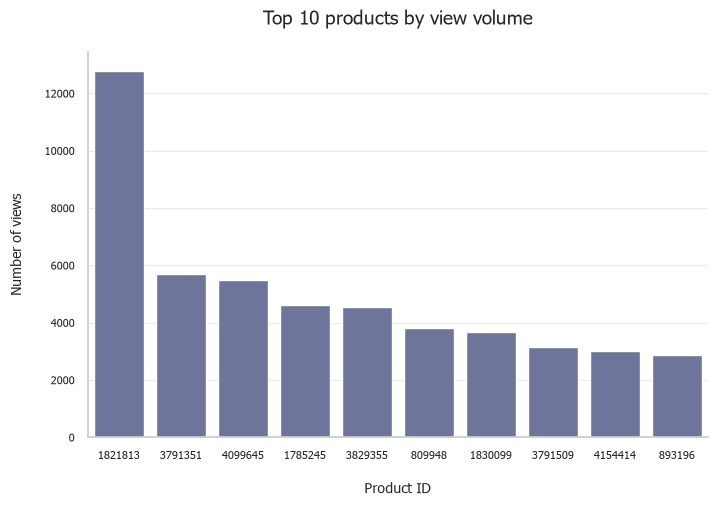

In [23]:
top_viewed_products = (
    product_summary
    .nlargest(10, "view_count")
    .sort_values("view_count")
)

product_order = (
    top_viewed_products
    .sort_values("view_count", ascending=False)["product_id"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=top_viewed_products,
    x='product_id',
    y='view_count',
    color=general_color,
    order=product_order,
    ax=ax
)
ax.set_title(
    'Top 10 products by view volume', 
    pad=20)
ax.set_xlabel(
    'Product ID', 
    labelpad=15)
ax.set_ylabel(
    'Number of views', 
    labelpad=15)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

### QUESTION 2: 
## Which categories show stronger or weaker conversion?

I will compare categories using a minimum view threshold. This avoids ranking
categories with very few observations and focuses the comparison on categories
with enough activity to be directionally useful.

In [24]:
category_summary = (
    events.groupby('category_level_1', as_index=False)
    .agg(
        event_count=('event_type', 'size'),
        view_count=('event_type', lambda values: (values == 'view').sum()),
        cart_count=('event_type', lambda values: (values == 'cart').sum()),
        purchase_count=('event_type', lambda values: (values == 'purchase').sum()),
        average_price=('price', 'mean')
    )
)

category_summary = add_event_rates(category_summary)
category_comparison = (
    category_summary[
        (category_summary['category_level_1'] != 'Unknown')
        & (category_summary['view_count'] >= 1_000)
    ]
    .sort_values('view_to_purchase_rate', ascending=False)
)

print('Category comparison using categories with at least 1000 views:')
display(category_comparison)

Category comparison using categories with at least 1000 views:


,category_level_1,event_count,view_count,cart_count,purchase_count,average_price,view_to_cart_rate,view_to_purchase_rate
14,stationery,42948,36796,3233,2919,50.26,8.79,7.93
5,computers,316660,272808,26982,16870,224.55,9.89,6.18
8,electronics,170949,155125,9056,6768,126.73,5.84,4.36
9,furniture,3364,3093,156,115,21.59,5.04,3.72
6,construction,31035,28674,1362,999,101.45,4.75,3.48
4,auto,35408,32858,1459,1091,115.24,4.44,3.32
1,accessories,2075,1953,66,56,53.91,3.38,2.87
3,appliances,41047,38938,1205,904,150.49,3.09,2.32
7,country_yard,3137,3072,42,23,352.48,1.37,0.75


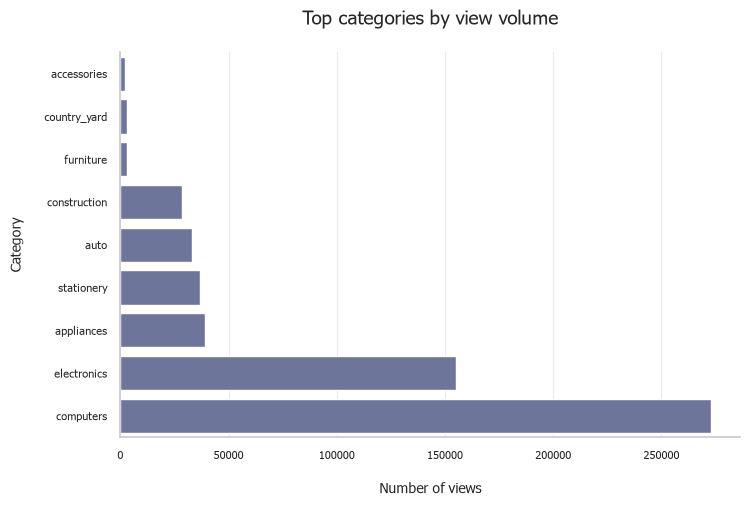

In [26]:
top_categories = category_comparison.nlargest(10, 'view_count').sort_values('view_count')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=top_categories,
    x='view_count',
    y='category_level_1',
    color=general_color,
    ax=ax
)
ax.set_title(
    'Top categories by view volume', 
    pad=20)

ax.set_xlabel(
    'Number of views', 
    labelpad=15)

ax.set_ylabel(
    'Category', 
    labelpad=15)

format_chart(ax)
ax.grid(axis="y", visible=False)

plt.show()

### QUESTION 3: 
## How does price relate to event-level conversion?

Price bands make the distribution easier to compare than a raw price
histogram. These rates are based on event counts, so they should be used as
directional indicators rather than customer-level conversion rates.

In [27]:
price_bins = [0, 25, 50, 100, 250, 500, 1_000, np.inf]
price_labels = ['0–25', '25–50', '50–100', '100–250', '250–500', '500–1,000', '1,000+']

events['price_band'] = pd.cut(
    events['price'],
    bins=price_bins,
    labels=price_labels,
    right=False
)

price_summary = (
    events.groupby('price_band', observed=False, as_index=False)
    .agg(
        event_count=('event_type', 'size'),
        view_count=('event_type', lambda values: (values == 'view').sum()),
        cart_count=('event_type', lambda values: (values == 'cart').sum()),
        purchase_count=('event_type', lambda values: (values == 'purchase').sum())
    )
)

price_summary = add_event_rates(price_summary)
display(price_summary)

,price_band,event_count,view_count,cart_count,purchase_count,view_to_cart_rate,view_to_purchase_rate
0,0–25,210677,190969,10954,8754,5.74,4.58
1,25–50,156888,140502,9167,7219,6.52,5.14
2,50–100,171975,156300,9246,6429,5.92,4.11
3,100–250,180903,160820,12085,7998,7.51,4.97
4,250–500,123485,107958,10005,5522,9.27,5.11
5,"500–1,000",33935,30160,2420,1355,8.02,4.49
6,"1,000+",6449,6234,149,66,2.39,1.06


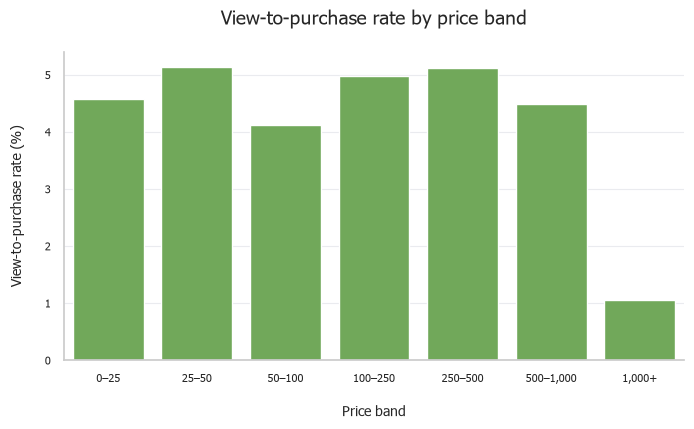

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=price_summary,
    x='price_band',
    y='view_to_purchase_rate',
    color=highlight_color,
    ax=ax
)

ax.set_title(
    'View-to-purchase rate by price band', 
    pad=20)

ax.set_xlabel(
    'Price band', 
    labelpad=15)

ax.set_ylabel(
    'View-to-purchase rate (%)', 
    labelpad=15)

format_chart(ax)
ax.grid(axis='x', visible=False)

plt.show()

### QUESTION 4: 
## Do more engaged sessions have stronger funnel outcomes?

I will group sessions by the number of recorded events and compare the share
of sessions that completed the chronological funnel. This helps distinguish
simple traffic volume from deeper engagement.

In [33]:
session_funnel['event_band'] = pd.cut(
    session_funnel['event_count'],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=['1', '2', '3', '4–5', '6–10', '11+'],
    right=True
)

session_engagement = (
    session_funnel.groupby('event_band', observed=False, as_index=False)
    .agg(
        session_count=('user_session', 'size'),
        view_sessions=('has_view', 'sum'),
        ordered_purchase_sessions=('valid_funnel_order', 'sum')
    )
)

session_engagement['ordered_purchase_rate'] = (
    session_engagement['ordered_purchase_sessions']
    .div(session_engagement['view_sessions'])
    .mul(100)
    .where(session_engagement['view_sessions'] > 0)
)

display(session_engagement)

,event_band,session_count,view_sessions,ordered_purchase_sessions,ordered_purchase_rate
0,1,350092,348382,0,0.00
1,2,68485,68258,0,0.00
2,3,29788,29731,5755,19.36
3,4–5,23015,22977,6903,30.04
4,6–10,13740,13725,5373,39.15
5,11+,5513,5513,2488,45.13


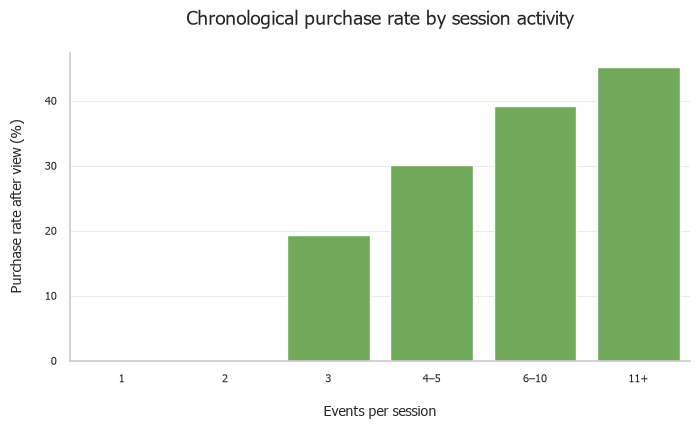

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=session_engagement,
    x='event_band',
    y='ordered_purchase_rate',
    color=highlight_color,
    ax=ax
)

ax.set_title(
    'Chronological purchase rate by session activity', 
    pad=20)
ax.set_xlabel(
    'Events per session', 
    labelpad=15)
ax.set_ylabel(
    'Purchase rate after view (%)', 
    labelpad=15)

format_chart(ax)
ax.grid(axis='x', visible=False)

plt.show()

### Business summary

The results are descriptive and should be used to prioritize further investigation. High-visibility products with low purchase rates may require review of pricing, availability, relevance, and product-page experience. Category and price comparisons should be interpreted with their event-based definitions and minimum-volume thresholds in mind. Additional analysis would be needed to test whether the observed differences are statistically meaningful.